In [1]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer, 
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

## 1. 환경 설정 및 데이터 로드

In [3]:
MODEL_ID = "klue/roberta-large"  # meta-llama/Llama-3.2-1B (llama) / klue/roberta-large ()
DATA_PATH = "data/dataset.xlsx"  # 파일 경로 확인
NUM_LABELS = 47
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

df = pd.read_excel(DATA_PATH)

df = df.dropna(subset=["text", "label"])
df["label"] = df["label"].astype(int)

# 데이터 분할 (7:1.5:1.5)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
})

## 2. 토크나이저 및 모델 설정

In [4]:
# 1) 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.padding_side = "right" 

# 2) 데이터 전처리 함수 및 콜레이터 설정
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_datasets = raw_datasets.map(tokenize_fn, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3) 모델 로드
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID, 
    num_labels=NUM_LABELS
)
model.to(DEVICE)
model.config.pad_token_id = tokenizer.pad_token_id

# 4) LoRA 설정 (target_modules 확장)
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16, 
    lora_alpha=32, 
    lora_dropout=0.1,
    target_modules=["query", "key", "value", "output.dense"]
)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

Map:   0%|          | 0/3150 [00:00<?, ? examples/s]

Map:   0%|          | 0/675 [00:00<?, ? examples/s]

Map:   0%|          | 0/675 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: klue/roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 6,209,583 || all params: 342,914,142 || trainable%: 1.8108


## 3. 평가 지표 정의 (Top-1, Top-3, F1)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits_t = torch.from_numpy(logits)
    labels_t = torch.from_numpy(labels)

    # Top-1 Acc
    preds = torch.argmax(logits_t, dim=-1)
    acc = (preds == labels_t).float().mean().item()

    # Top-3 Acc
    _, top3_preds = torch.topk(logits_t, k=3, dim=-1)
    top3_acc = (top3_preds == labels_t.unsqueeze(-1)).any(dim=-1).float().mean().item()


    return {"accuracy": acc, "top3_accuracy": top3_acc}

## 4. 학습 실행 (Training)

In [8]:
train_dataset = tokenized_datasets["train"].remove_columns(["text"])
eval_dataset = tokenized_datasets["validation"].remove_columns(["text"])

training_args = TrainingArguments(
    output_dir="./roberta-intent-results",
    learning_rate=1e-4,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=20,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    bf16=False,
    logging_steps=5,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    # tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("학습을 시작합니다...")
trainer.train()

학습을 시작합니다...


c:\Users\USER\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

## 5. 최종 상세 분석 (Per-label & Confusion Matrix)


최종 테스트 세트 상세 분석



[Classification Report]
              precision    recall  f1-score   support

           0     0.7333    0.8462    0.7857        13
           1     0.7273    0.5714    0.6400        14
           2     0.7368    0.8235    0.7778        17
           3     0.6429    0.6429    0.6429        14
           4     0.6250    0.7143    0.6667        14
           5     0.8000    0.7500    0.7742        16
           6     0.8000    0.6667    0.7273        12
           7     0.6429    0.7500    0.6923        12
           8     0.7000    0.5385    0.6087        13
           9     0.5000    0.6667    0.5714        12
          10     0.5333    0.6154    0.5714        13
          11     0.7778    0.5833    0.6667        12
          12     0.8571    0.8571    0.8571        14
          13     0.9091    0.7143    0.8000        14
          14     0.8571    0.4286    0.5714        14
          15     0.9333    1.0000    0.9655        14
          16     1.0000    0.7857    0.8800        14
  

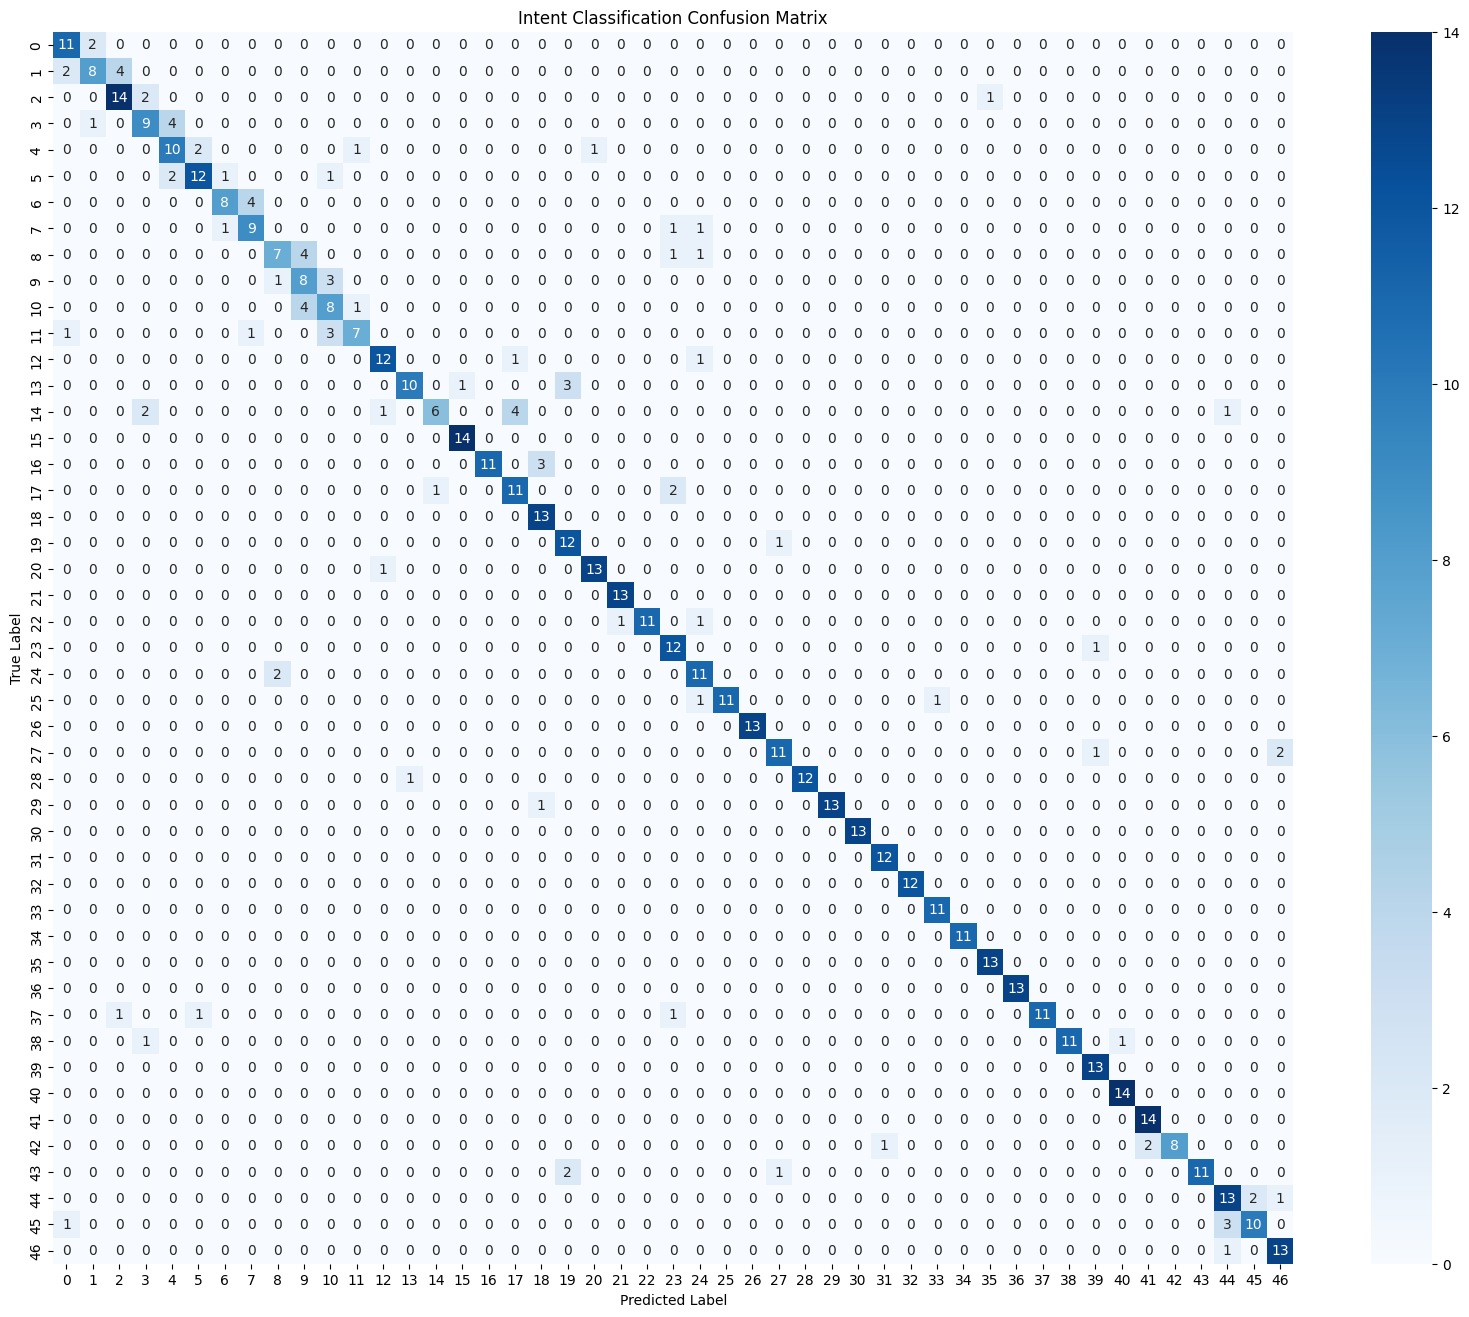

In [ ]:
print("\n최종 테스트 세트 상세 분석")

test_dataset = tokenized_datasets["test"].remove_columns(["text"])
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# 1) 레이블별 지표 출력 및 저장
report = classification_report(y_true, y_pred, digits=4)
print("\n[Classification Report]")
print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)

# 2) Confusion Matrix 시각화
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(NUM_LABELS), yticklabels=range(NUM_LABELS))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Intent Classification Confusion Matrix')
plt.savefig('confusion_matrix.png')
print("혼동 행렬 이미지가 'confusion_matrix.png'로 저장.")

# 3) 최종 핵심 지표 요약
#test_metrics = trainer.evaluate(test_dataset)
#print(f"\n최종 결과: Top-1 Acc: {test_metrics['eval_accuracy']:.4f} | Top-3 Acc: {test_metrics['eval_top3_accuracy']:.4f}")

print(f"\n최종 결과: Top-1 Acc: {predictions.metrics['test_accuracy']:.4f}")
if 'test_top3_accuracy' in predictions.metrics:
    print(f"최종 결과: Top-3 Acc: {predictions.metrics['test_top3_accuracy']:.4f}")
elif 'test_f1_macro' in predictions.metrics:
    print(f"최종 결과: F1 Macro: {predictions.metrics['test_f1_macro']:.4f}")

## 6. 실전 문장 입력 테스트

In [ ]:
def predict_ui(text):
    model.eval()
    # 
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(DEVICE)
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        
    probs = torch.nn.functional.softmax(logits, dim=-1)
    top3_probs, top3_indices = torch.topk(probs, k=3)
    
    print(f"\n사용자 입력: \"{text}\"")
    print("-" * 35)
    for i in range(3):
        idx = top3_indices[0][i].item()
        conf = top3_probs[0][i].item()
        print(f"[{i+1}순위] UI 레이블 {idx:2d} (확률: {conf:.2%})")

# 원하는 문장으로 테스트
predict_ui("통장 잔액 좀 알려줘")
predict_ui("카드 결제일 변경하고 싶어")
predict_ui("해외에서 돈 보내려면 어떻게 해?")
predict_ui("통장사본 어디있어")


사용자 입력: "통장 잔액 좀 알려줘"
-----------------------------------
[1순위] UI 레이블  3 (확률: 32.06%)
[2순위] UI 레이블 12 (확률: 26.57%)
[3순위] UI 레이블  2 (확률: 23.45%)

사용자 입력: "카드 결제일 변경하고 싶어"
-----------------------------------
[1순위] UI 레이블 19 (확률: 68.57%)
[2순위] UI 레이블 43 (확률: 8.32%)
[3순위] UI 레이블 44 (확률: 4.18%)

사용자 입력: "해외에서 돈 보내려면 어떻게 해?"
-----------------------------------
[1순위] UI 레이블 23 (확률: 85.42%)
[2순위] UI 레이블  8 (확률: 3.69%)
[3순위] UI 레이블 24 (확률: 3.42%)

사용자 입력: "통장사본 어디있어"
-----------------------------------
[1순위] UI 레이블 12 (확률: 42.27%)
[2순위] UI 레이블  3 (확률: 24.08%)
[3순위] UI 레이블  2 (확률: 12.89%)
